# Visualize BPT Coalitions

In [76]:
import numpy as np
import json
import sys, os, importlib, math
import random as random
import matplotlib.pyplot as plt
import cv2
from tqdm.auto import tqdm
from skimage.segmentation import mark_boundaries
import io, imageio

from matplotlib import rc
rc('text',usetex=True)
rc('text.latex', preamble='\\usepackage{color}')

import shap_bpt as shap_bpt
print(shap_bpt.__version__)

1.0.2


In [77]:
# import imageio as iio
# from skimage.transform import resize
import hashlib

def load_rgb_image_from_file(filename):
    return cv2.imread(filename, cv2.IMREAD_COLOR)[:,:,::-1]

    
    image = iio.imread(filename)
    if len(image.shape)==2: # grayscale
        image = np.repeat(image[:, :, None], 3, axis=2)
    if image.shape[2]==4:
        image = image[:, :, 0:3]

#     print(hashlib.sha1( np.ascontiguousarray(image).view(np.uint8) ).hexdigest())

    # if image.shape != size:
    #     print(image)
    #     image = resize(image/255.0, size)*255
    #     print(image)
    return image.astype(np.uint8)

# image_to_explain = load_rgb_image_from_file('../imgs/flamingo.png')
# _ = load_rgb_image_from_file('../imgs/ImageNet-S/ILSVRC2012_val_00000089.png')


In [78]:
image_ids = os.listdir("../partitions")


In [79]:
# get list of all images with file



In [80]:
import os
from pathlib import Path
import yaml

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / 'pyproject.toml').exists() and (path / 'shap_bpt').is_dir():
            return path
    raise FileNotFoundError('Could not find the project root from the current working directory.')

original_working_dir = Path.cwd()
project_root = find_project_root(original_working_dir)
os.chdir(project_root)
print(f'Project root: {project_root}')

config_file = "MSCOCO_mac"
# config_file = "MSCOCO_xn2"

try:
    with open(project_root / f"examples/configs/{config_file}.yaml", "r") as f:
        config = yaml.safe_load(f)
finally:
    os.chdir(original_working_dir)
    print(f'Restored working directory: {original_working_dir}')

dataset_root = config["data"]["dataset_root"]
print(f"Dataset root: {dataset_root}")

Project root: /Users/rashid/Nextcloud/RashidPHD/Codes/XAI/ShapBPT-SAM/shap_bpt_sam
Restored working directory: /Users/rashid/Nextcloud/RashidPHD/Codes/XAI/ShapBPT-SAM/shap_bpt_sam/examples/notebooks
Dataset root: /Users/rashid/data/DS/MS_COCO


In [81]:
## Get available precomputed SAM partitions
# fetch available unique image_ids from the partitions directory
image_ids = os.listdir("../partitions")
image_ids = [f.split('.')[0].split('_')[0] for f in image_ids if '_refined.npy' in f]
print(f'computed image_ids: {len(image_ids)}')

already_computed = ['000000049091',
 '000000000632',
 '000000186929',
 '000000002299',
 '000000225757',
 '000000171382']

image_ids = [img_id for img_id in image_ids if img_id not in already_computed]
print(f'filtered image_ids: {len(image_ids)}')
image_ids
image_dir = config["data"]["image_dir"] # Update for your image directory

computed image_ids: 30
filtered image_ids: 24


In [82]:
image_id = '000000170670'  # Example image ID
image_path = os.path.join(image_dir, f'{image_id}.jpg')

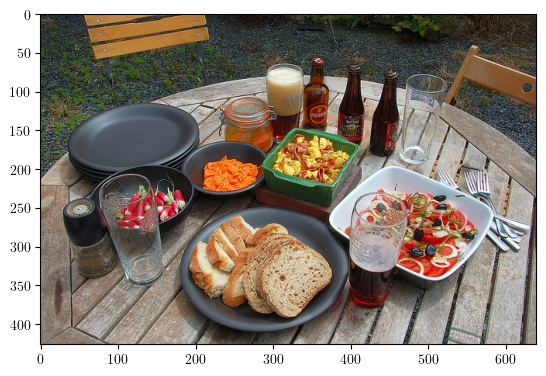

In [83]:
image_to_explain = load_rgb_image_from_file(image_path)
plt.imshow(image_to_explain)
plt.show()

In [84]:
%%time
bptree = shap_bpt.build_bpt_from_image(image_to_explain.astype('uint8'))

CPU times: user 670 ms, sys: 31.1 ms, total: 701 ms
Wall time: 733 ms


In [85]:
base_segment = shap_bpt.BaseSegment()

In [86]:
np.random.seed(1234)
# voronoi_diagram = shap_bpt.VoronoiDiagram(image_to_explain.shape[1], image_to_explain.shape[0], 50)
# voronoi_diagram = shap_bpt.voronoi_segmentation(image_to_explain.shape[1], image_to_explain.shape[0], 50)
# voronoi_diagram.plot()
# plt.imshow(voronoi_diagram.cell_matrix.transpose(), cmap='terrain')
# plt.scatter(voronoi_diagram.centers_x, voronoi_diagram.centers_y, c='w', edgecolors='k')
plt.show()

In [87]:
def colorize(nodes, img, i=0):
    is_aa = isinstance(nodes[0], shap_bpt.AxisAlignedSegment)
    height, width = img.shape[:2]
    pxflat_image = img.reshape((height * width, img.shape[-1]))
    colored = np.zeros_like(img, dtype=np.float32)
    flat_colored = colored.reshape(pxflat_image.shape)
    for node in nodes:
        if is_aa:
            region = img[node.ymin:node.ymax, node.xmin:node.xmax, :]
            clr = region.mean(axis=(0, 1)) / 255.0
            colored[node.ymin:node.ymax, node.xmin:node.xmax] = clr
        else:
            s, e = node.pixels_interval()
            pixels = node.bpt.pixels[s:e]
            clr = pxflat_image[pixels].mean(axis=0) / 255.0
            flat_colored[pixels, :] = clr
    return colored


def make_segments(nodes, img):
    is_aa = isinstance(nodes[0], shap_bpt.AxisAlignedSegment)
    segments = np.zeros(img.shape[:2], dtype=np.uint32)
    flat_segments = segments.ravel()
    for i, node in enumerate(nodes):
        if is_aa:
            segments[node.ymin:node.ymax, node.xmin:node.xmax] = i
        else:
            s, e = node.pixels_interval()
            flat_segments[node.bpt.pixels[s:e]] = i
    return segments


def make_boundary_overlay(segment_labels, cut_color=(0.5, 0, 0.25, 1)):
    height, width = segment_labels.shape[:2]
    transparent = np.zeros((height, width, 4), dtype=np.float32)
    boundaries = mark_boundaries(
        transparent,
        segment_labels,
        mode='thick',
        color=cut_color,
    )
    cut_mask = np.all(np.isclose(boundaries, cut_color), axis=-1)
    boundaries[cut_mask] = (0, 0, 0, 1)
    return boundaries


def expand_tree_once(segments, all_nodes=None):
    new_segments = []
    leaf_count = 0
    for segment in segments:
        split = segment.split(segment, segment)
        if split is None:
            new_segments.append(segment)
            leaf_count += 1
        else:
            new_segments.extend(split)
            if all_nodes is not None:
                all_nodes.extend(split)
    return new_segments, leaf_count



def image_width_height(img):
    height, width = img.shape[:2]
    return width, height


def make_aa_root_for_image(img, base_segment=None):
    width, height = image_width_height(img)
    return shap_bpt.AxisAlignedSegment(0, width, 0, height, base_segment)


def grid_shape(n_items, max_cols=8):
    if n_items <= 0:
        return 1, 1
    nc = min(max_cols, n_items)
    nr = int(np.ceil(n_items / nc))
    return nr, nc


def image_aspect_from_shape(shape):
    height, width = shape[:2]
    return width / max(height, 1)


def set_image_axes(ax, image_shape):
    height, width = image_shape[:2]
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])


def plot_targets_grid(targets, img, max_cols=8, cell_height=1.5):
    nr, nc = grid_shape(len(targets), max_cols=max_cols)
    aspect = image_aspect_from_shape(img.shape)
    fig, axes = plt.subplots(
        nr,
        nc,
        figsize=(nc * cell_height * aspect, nr * cell_height),
        squeeze=False,
    )
    axes_flat = axes.ravel()
    for i, ax in enumerate(axes_flat):
        if i >= len(targets):
            ax.axis('off')
            continue
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        targets[i].fill_mask(mask, False)
        ax.imshow(~mask.astype(bool), cmap='gray', aspect='equal')
        set_image_axes(ax, mask.shape)
        ax.set_title(f'Target {i}')
    plt.tight_layout()
    return fig, axes


def plot_patch_grid(patches, max_cols=8, save_path=None, cell_height=1.05):
    nr, nc = grid_shape(len(patches), max_cols=max_cols)
    if len(patches) > 0:
        first_mask = np.asarray(patches[0][0])
        aspect = image_aspect_from_shape(first_mask.shape)
    else:
        aspect = 1.0
    fig, axes = plt.subplots(
        nr,
        nc,
        figsize=(nc * cell_height * aspect, nr * cell_height),
        squeeze=False,
    )
    axes_flat = axes.ravel()
    for i, ax in enumerate(axes_flat):
        if i >= len(patches):
            ax.axis('off')
            continue
        mask, coalition = patches[i]
        mask = np.asarray(mask)
        ax.imshow(mask, cmap='Greys', vmin=0, vmax=3, aspect='equal')
        set_image_axes(ax, mask.shape)
        coalition.plot(ax, color=(0, 0, 0, 1.0))
        set_image_axes(ax, mask.shape)
    plt.tight_layout(pad=0.1)
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight', pad_inches=0.02)
    return fig, axes


In [88]:
# image_to_explain = I_A_u8

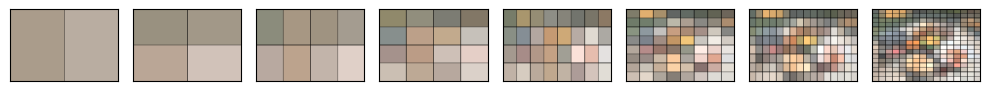

In [90]:
base_segment = shap_bpt.BaseSegment()
root_node, name = make_aa_root_for_image(image_to_explain, base_segment), 'AA'
# root_node, name = shap_bpt.BPT_Segment(bptree, bptree.N-1, base_segment), 'BPT'
segments = [root_node]
all_nodes = [root_node]
prev_boundaries = None

K = 8
leaves = np.zeros(K + 1, dtype=int)
fig, axes = plt.subplots(1, K, figsize=(10, 4))
axes = np.atleast_1d(axes).ravel()

for ii in range(K + 1):
    img = colorize(segments, image_to_explain)
    img = np.clip(0.2 + img * 1.1, 0, 1)
    sgm = make_segments(segments, image_to_explain)
    boundaries = make_boundary_overlay(sgm)

    if ii >= 1:
        ax = axes[ii - 1]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(img)
        ax.imshow(boundaries)
        if prev_boundaries is not None:
            ax.imshow(prev_boundaries)
        # ax.set_title(f'depth={ii}, $n$={len(segments)}', fontsize=20)

    prev_boundaries = boundaries
    segments, leaves[ii] = expand_tree_once(segments, all_nodes)

plt.tight_layout()
os.makedirs('paper_figures', exist_ok=True)
plt.savefig(f'paper_figures/figure1_C_{name}_expansion.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()


## BPT

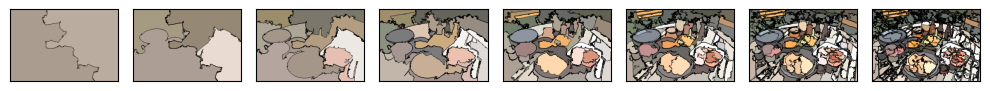

In [91]:
base_segment = shap_bpt.BaseSegment()
# root_node, name = make_aa_root_for_image(image_to_explain, base_segment), 'AA'
root_node, name = shap_bpt.BPT_Segment(bptree, bptree.N-1, base_segment), 'BPT'
segments = [root_node]
all_nodes = [root_node]
prev_boundaries = None

K = 8
leaves = np.zeros(K + 1, dtype=int)
fig, axes = plt.subplots(1, K, figsize=(10, 4))
axes = np.atleast_1d(axes).ravel()

for ii in range(K + 1):
    img = colorize(segments, image_to_explain)
    img = np.clip(0.2 + img * 1.1, 0, 1)
    sgm = make_segments(segments, image_to_explain)
    boundaries = make_boundary_overlay(sgm)

    if ii >= 1:
        ax = axes[ii - 1]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(img)
        ax.imshow(boundaries)
        if prev_boundaries is not None:
            ax.imshow(prev_boundaries)
        # ax.set_title(f'depth={ii}, $n$={len(segments)}', fontsize=20)

    prev_boundaries = boundaries
    segments, leaves[ii] = expand_tree_once(segments, all_nodes)

plt.tight_layout()
os.makedirs('paper_figures', exist_ok=True)
plt.savefig(f'paper_figures/figure1_C_{name}_expansion.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()


# Recursive patches

In [92]:
importlib.reload(shap_bpt)
def empty_nu(img):
    return np.zeros((3,1))
explainer = shap_bpt.Explainer(empty_nu, image_to_explain, num_explained_classes=3, verbose=False)

targets = []
def enum_targets(aa, depth):
    if depth==0:
        targets.append(aa)
    else:
        aa1, aa2 = aa.split(None, None)
        enum_targets(aa1, depth-1)
        enum_targets(aa2, depth-1)

In [93]:
s0 = shap_bpt.BPT_Segment(bptree, bptree.N-1, None) ; 
enum_targets(s0, 4)

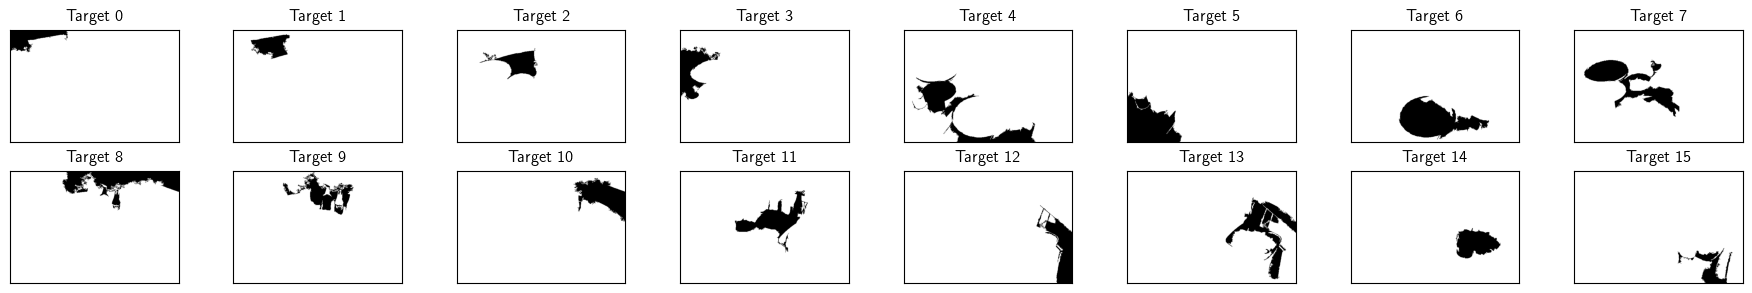

In [94]:
fig, axes = plot_targets_grid(targets, image_to_explain, max_cols=8)
plt.show()


In [95]:
coal_num = 8 ; coal_t='bpt'
# coal_num = 10 ; coal_t='bpt'

In [96]:
list_of_patches = None
def Phi(S, T):
    global explainer, list_of_patches
    for Ci in S:
        if Ci.equals(T):
            mask = explainer.empty_mask()
            patch_num = 1
            for C in S:
                if not C.equals(T):
                    C.fill_mask(mask, False)
            vS = explainer.predict_masked([mask])
            if list_of_patches is not None:
                list_of_patches.append((mask, Ci))
            Ci.fill_mask(mask, False)
            return
        elif Ci.contains(T):
            Si = [Cj for Cj in S if not Cj.equals(Ci)]
            Ci1, Ci2 = Ci.split(None, None)
            if Ci2.contains(T):
                Ci1, Ci2 = Ci2, Ci1
                
            Phi(Si + [Ci1], T)
            Phi(Si + [Ci1, Ci2], T)
            return
    assert False

In [97]:
def get_list_of_patches(S, T):
    global list_of_patches
    list_of_patches = []
    Phi(S, T)
    l, list_of_patches = list_of_patches, None
    return l

coal_num = min(coal_num, len(targets) - 1)
lp = get_list_of_patches([s0], targets[coal_num])
print(len(targets), len(lp))

16 16


### Figure 1 : D (BPT)

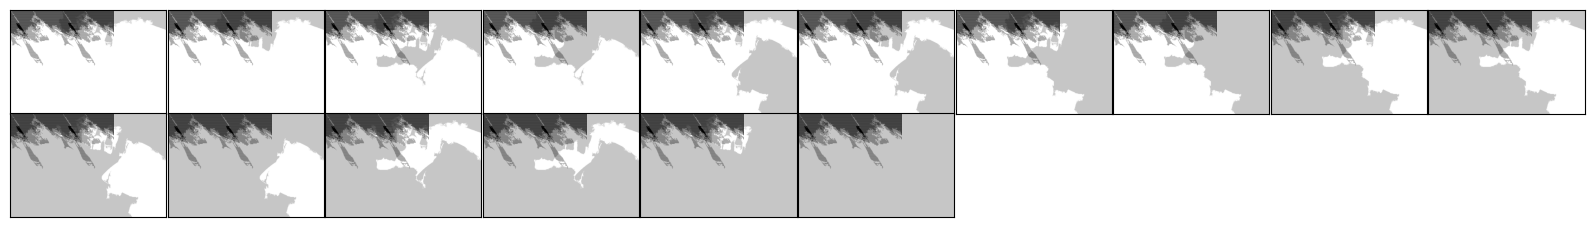

In [98]:
fig, axes = plot_patch_grid(lp, max_cols=10)
# fig.savefig(f'paper_figures/figure1_D_coalitions_{coal_t}.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()


In [99]:
importlib.reload(shap_bpt)
def empty_nu(img):
    return np.zeros((3,1))
explainer = shap_bpt.Explainer(empty_nu, image_to_explain, num_explained_classes=3, verbose=False)

targets = []
def enum_targets(aa, depth):
    if depth==0:
        targets.append(aa)
    else:
        aa1, aa2 = aa.split(None, None)
        enum_targets(aa1, depth-1)
        enum_targets(aa2, depth-1)

In [100]:
s0 = make_aa_root_for_image(image_to_explain, None)
enum_targets(s0, 4)


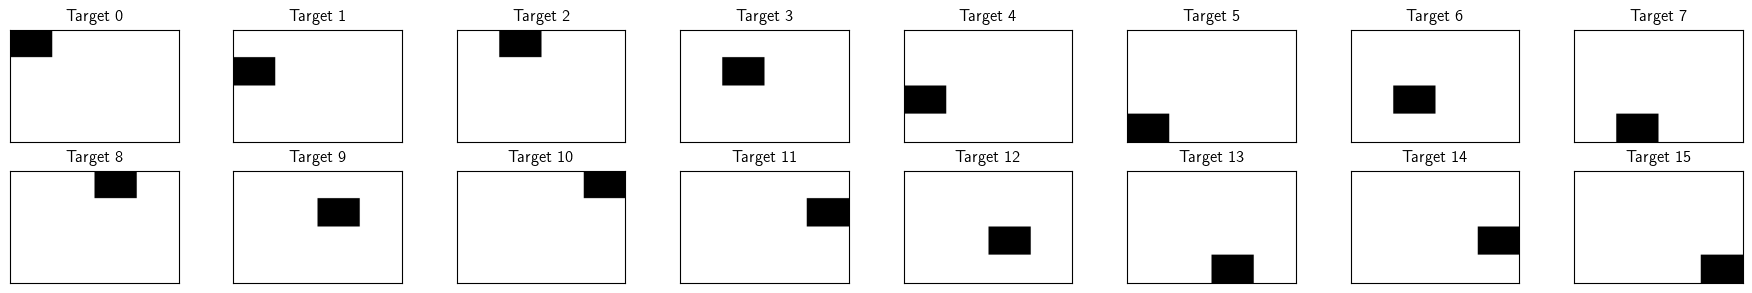

In [101]:
fig, axes = plot_targets_grid(targets, image_to_explain, max_cols=8)
plt.show()


In [102]:
coal_num = 8 ; coal_t='aa'
# coal_num = 6 ; coal_t='aa'

In [103]:
list_of_patches = None
def Phi(S, T):
    global explainer, list_of_patches
    for Ci in S:
        if Ci.equals(T):
            mask = explainer.empty_mask()
            patch_num = 1
            for C in S:
                if not C.equals(T):
                    C.fill_mask(mask, False)
            vS = explainer.predict_masked([mask])
            if list_of_patches is not None:
                list_of_patches.append((mask, Ci))
            Ci.fill_mask(mask, False)
            return
        elif Ci.contains(T):
            Si = [Cj for Cj in S if not Cj.equals(Ci)]
            Ci1, Ci2 = Ci.split(None, None)
            if Ci2.contains(T):
                Ci1, Ci2 = Ci2, Ci1
                
            Phi(Si + [Ci1], T)
            Phi(Si + [Ci1, Ci2], T)
            return
    assert False

In [104]:
coal_num = min(coal_num, len(targets) - 1)
lp = get_list_of_patches([s0], targets[coal_num])
print(len(targets), len(lp))

16 16


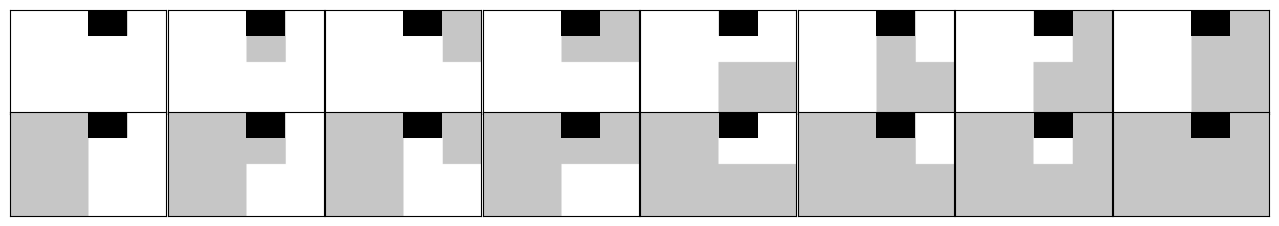

In [105]:
fig, axes = plot_patch_grid(
    lp,
    max_cols=8,
    save_path=f'paper_figures/figure1_D_coalitions_{coal_t}.svg',
)
plt.show()


## FOR ALL IMAGES

In [106]:
def build_bpt_from_image(img_, partitions_sorted,partitions_refined):
    bptrees = {}

    bptrees['BPT'] = shap_bpt.build_bpt_from_image(img_)

    bptrees['SAM_S'] = shap_bpt.build_bpt_from_image(img_,
                                                    use_perim_term=False,use_area_term=False,use_color_term=False,
                                                    prebuilt_partitions=partitions_sorted)
    bptrees['SAM_R'] = shap_bpt.build_bpt_from_image(img_,
                                                use_perim_term=False,use_area_term=False,use_color_term=False,
                                                prebuilt_partitions=partitions_refined)
    bptrees['BPT+SAM_S'] = shap_bpt.build_bpt_from_image(img_,
                                                    prebuilt_partitions=partitions_refined)
    bptrees['BPT+SAM_R'] = shap_bpt.build_bpt_from_image(img_,
                                                    prebuilt_partitions=partitions_refined)
    return bptrees

In [107]:
save_path = f"{path_results}/{image_id}_partition_expansion.png"
bptrees = build_bpt_from_image(image_to_explain, partitions_sorted,partitions_refined)
plot_coalitions(image_to_explain,bptrees,masks_sorted, masks_refined, save_path=save_path, fontsize=14)

NameError: name 'path_results' is not defined

In [ ]:
import pandas as pd

In [ ]:
data_to_csv = []
for image_id in tqdm(image_ids):
    print('='*100)
    image_dir = config["data"]["image_dir"] # Update for your image directory
    annotation_file =  config["data"]["annotation_file"] # Update for your annotation file

    # image_id = '000000170670'  # Example image ID
    image_path = os.path.join(image_dir, f'{image_id}.jpg')

    image_to_explain = load_rgb_image_from_file(image_path)
    
    print(image_id)
    masks_sorted = np.load(f"../partitions/{image_id}_sorted.npy").astype(np.uint16)
    masks_refined = np.load(f"../partitions/{image_id}_refined.npy").astype(np.uint16)

    partitions = uts.cap_partition_labels(masks_sorted, max_labels=63)
    partitions_sorted = uts.sanitize_partitions(partitions, image_to_explain.shape, max_labels=63)

    partitions = uts.cap_partition_labels(masks_refined, max_labels=63)
    partitions_refined = uts.sanitize_partitions(partitions, image_to_explain.shape, max_labels=63)

    lms = len(np.unique(masks_sorted))
    lmr = len(np.unique(masks_refined))

    bptrees = build_bpt_from_image(image_to_explain, partitions_sorted,partitions_refined)
    save_path = f"{path_results}/{image_id}_partition_expansion.png"
    plot_coalitions(image_to_explain,bptrees,masks_sorted, masks_refined, save_path=save_path, fontsize=14)
    
    data = {'image_id': image_id, 'lms': lms, 'lmr': lmr}
    data_to_csv.append(data)
df = pd.DataFrame(data_to_csv)


In [ ]:
df = pd.DataFrame(data_to_csv)
df.to_csv(f"{path_results}/partition_summary.csv", index=False)


In [ ]:
df.head(10)